## 1)Train

### 1.1 IMPORTS

In [2]:
import os
import random
import librosa
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import cv2

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

### 1.2 CONFIG

In [3]:
DATA_PATH = "../data/ASVspoof2019_LA"
PROTOCOL_PATH = os.path.join(DATA_PATH, "ASVspoof2019_LA_cm_protocols")

SR = 16000
DURATION = 3
N_MELS = 128
IMG_SIZE = 128

BATCH_SIZE = 16
EPOCHS = 10

### 1.3 DEVICE

In [4]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

Using device: mps


### 1.4 PARSE

In [5]:
def parse_protocol(file_path):
    files, labels = [], []

    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            files.append(parts[1])
            labels.append(1 if parts[-1] == "spoof" else 0)

    return files, labels

### 1.5 LOAD DATA

In [6]:
train_protocol = os.path.join(PROTOCOL_PATH, "ASVspoof2019.LA.cm.train.trn.txt")

filenames, labels = parse_protocol(train_protocol)

subset_size = 1500
combined = list(zip(filenames, labels))
random.shuffle(combined)
combined = combined[:subset_size]

filenames, labels = zip(*combined)

files = [
    os.path.join(DATA_PATH, "ASVspoof2019_LA_train/flac", f"{f}.flac")
    for f in filenames
]

labels = list(labels)

### 1.6 SPLIT

In [7]:
train_files, val_files, train_labels, val_labels = train_test_split(
    files, labels, test_size=0.2, stratify=labels
)

### 1.7 AUDIO → MEL

In [8]:
def audio_to_mel(path):
    y, _ = librosa.load(path, sr=SR)

    max_len = SR * DURATION
    y = y[:max_len] if len(y) > max_len else np.pad(y, (0, max_len - len(y)))

    mel = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=N_MELS)
    mel = librosa.power_to_db(mel, ref=np.max)

    mel = (mel - mel.mean()) / (mel.std() + 1e-6)
    mel = cv2.resize(mel, (IMG_SIZE, IMG_SIZE))

    return mel

### 1.8 DATASET

In [9]:
class AudioDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        mel = audio_to_mel(self.files[idx])
        mel = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel, label

### 1.9 DATALOADER

In [10]:
train_dataset = AudioDataset(train_files, train_labels)
val_dataset = AudioDataset(val_files, val_labels)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

### 1.10 MODEL

In [11]:
class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2)

        self.fc1 = nn.Linear(32 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x, explain=False):
        x = self.pool(F.relu(self.conv1(x)))

        x = self.conv2(x)

        if explain:
            self.feature_maps = x
            x.register_hook(self.save_gradients)

        x = self.pool(F.relu(x))

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

    def save_gradients(self, grad):
        self.gradients = grad

### 1.11 TRAINING

In [12]:
model = CNNModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 26.0579
Epoch 2, Loss: 12.7322
Epoch 3, Loss: 6.3664
Epoch 4, Loss: 3.3208
Epoch 5, Loss: 1.2245
Epoch 6, Loss: 0.2579
Epoch 7, Loss: 0.0595
Epoch 8, Loss: 0.0366
Epoch 9, Loss: 0.0240
Epoch 10, Loss: 0.0184


### 1.12 EVALUATE

In [13]:
def evaluate(loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            preds = torch.argmax(model(X), dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

print("Validation Accuracy:", evaluate(val_loader))

Validation Accuracy: 0.9633333333333334


### 1.13 GRAD-CAM

In [14]:
def generate_gradcam(model, input_tensor, target_class):
    model.eval()

    input_tensor = input_tensor.unsqueeze(0).to(device)

    output = model(input_tensor, explain=True)

    model.zero_grad()
    output[0, target_class].backward()

    gradients = model.gradients
    activations = model.feature_maps

    weights = gradients.mean(dim=(2, 3), keepdim=True)
    cam = (weights * activations).sum(dim=1).squeeze()

    cam = torch.relu(cam).detach().cpu().numpy()
    cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    cam = (cam - cam.min()) / (cam.max() + 1e-8)

    return cam

### 1.14 VISUALIZE

In [15]:
def visualize_all(mel, cam):
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title("Mel Spectrogram")
    plt.imshow(mel, origin='lower')

    plt.subplot(1,3,2)
    plt.title("Grad-CAM")
    plt.imshow(cam, cmap='jet')

    plt.subplot(1,3,3)
    plt.title("Overlay")
    plt.imshow(mel, cmap='gray', origin='lower')
    plt.imshow(cam, cmap='jet', alpha=0.5)

    plt.show()

### 1.15 EXPLANATION

In [16]:
def generate_explanation(cam, pred, confidence):\
    # Normalize
    cam = (cam - cam.min()) / (cam.max() + 1e-8)

    # High attention mask
    high = cam > 0.6

    # Frequency analysis (vertical axis)
    freq_profile = np.sum(high, axis=1)

    # Time analysis (horizontal axis)
    time_profile = np.sum(high, axis=0)

    high_freq_strength = np.mean(freq_profile[-40:])
    low_freq_strength = np.mean(freq_profile[:40])

    temporal_variation = np.std(time_profile)

    explanation = ""

    if confidence > 0.9:
        explanation += "The model is highly confident in its prediction. "
    elif confidence > 0.7:
        explanation += "The model is moderately confident. "
    else:
        explanation += "The model has low confidence, suggesting ambiguity in the audio. "

    if pred == 1:
        explanation += "It predicts the audio is FAKE because "

        if high_freq_strength > low_freq_strength:
            explanation += "it detects strong high-frequency artifacts, which are typical in synthetic or AI-generated speech. "

        if temporal_variation > 5:
            explanation += "There are irregular temporal patterns, indicating unnatural transitions in the signal. "

        explanation += "These characteristics are commonly associated with deepfake audio."

    else:
        explanation += "It predicts the audio is REAL because "

        if low_freq_strength >= high_freq_strength:
            explanation += "the signal shows consistent low-frequency structure typical of natural speech. "

        if temporal_variation < 5:
            explanation += "The temporal patterns are smooth and continuous, indicating natural vocal transitions. "

        explanation += "This aligns with characteristics of authentic human speech."

    return explanation

### 1.16 FINAL TEST

Prediction: Fake
Confidence: 100.0 %

Explanation:
The model is highly confident in its prediction. It predicts the audio is FAKE because These characteristics are commonly associated with deepfake audio.


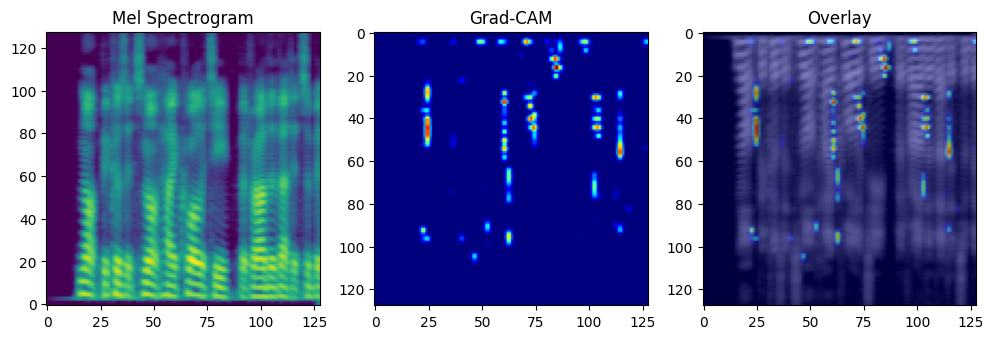

In [17]:
sample, label = val_dataset[0]

output = model(sample.unsqueeze(0).to(device))
pred = torch.argmax(output).item()

probs = torch.softmax(output, dim=1)
confidence = probs[0][pred].item()

cam = generate_gradcam(model, sample, pred)

print("Prediction:", "Fake" if pred else "Real")
print("Confidence:", round(confidence * 100, 2), "%")

print("\nExplanation:")
print(generate_explanation(cam, pred, confidence))

visualize_all(sample.squeeze().numpy(), cam)

## 2)TEST

### 2.1 TEST SINGLE SAMPLE

True Label: Fake
Prediction: Fake
Confidence: 100.0 %

Explanation:
The model is highly confident in its prediction. It predicts the audio is FAKE because These characteristics are commonly associated with deepfake audio.


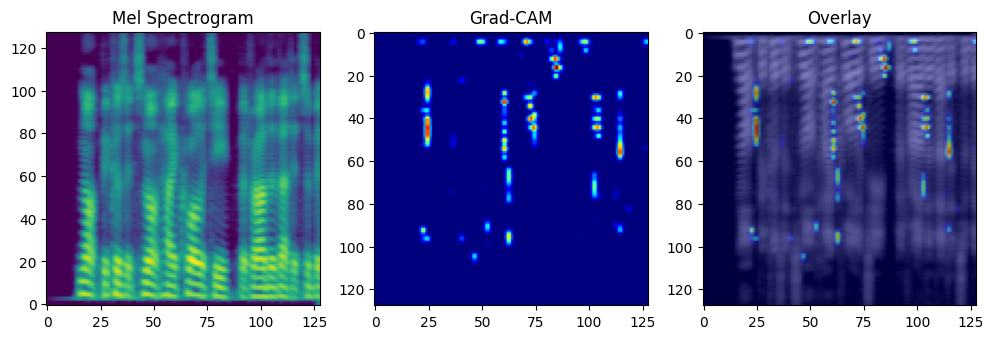

In [18]:
# Test one sample
sample, label = val_dataset[0]

output = model(sample.unsqueeze(0).to(device))
pred = torch.argmax(output).item()

probs = torch.softmax(output, dim=1)
confidence = probs[0][pred].item()

cam = generate_gradcam(model, sample, pred)

print("True Label:", "Fake" if label else "Real")
print("Prediction:", "Fake" if pred else "Real")
print("Confidence:", round(confidence * 100, 2), "%")

print("\nExplanation:")
print(generate_explanation(cam, pred, confidence))

visualize_all(sample.squeeze().numpy(), cam)

### 2.2 TEST MULTIPLE SAMPLES


===== SAMPLE 0 =====
True Label: Fake
Prediction: Fake
Confidence: 100.0 %
Explanation:
The model is highly confident in its prediction. It predicts the audio is FAKE because These characteristics are commonly associated with deepfake audio.


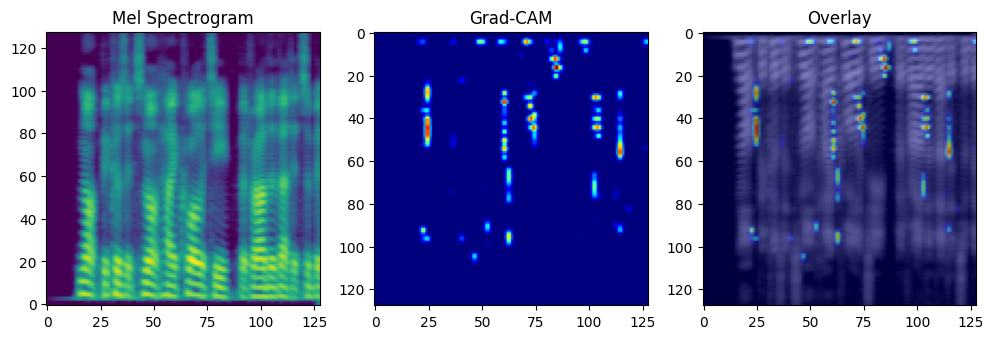


===== SAMPLE 1 =====
True Label: Fake
Prediction: Fake
Confidence: 100.0 %
Explanation:
The model is highly confident in its prediction. It predicts the audio is FAKE because These characteristics are commonly associated with deepfake audio.


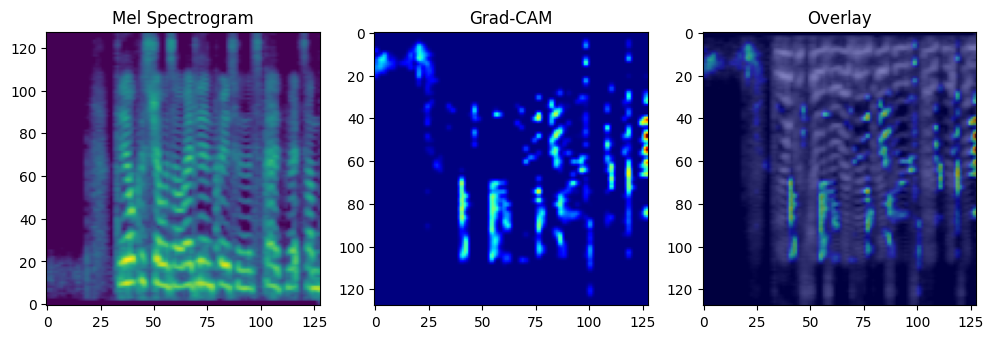


===== SAMPLE 2 =====
True Label: Fake
Prediction: Fake
Confidence: 100.0 %
Explanation:
The model is highly confident in its prediction. It predicts the audio is FAKE because These characteristics are commonly associated with deepfake audio.


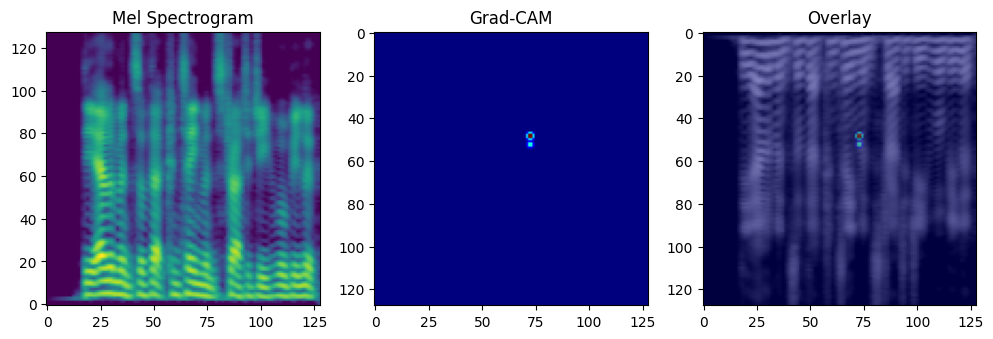


===== SAMPLE 3 =====
True Label: Fake
Prediction: Fake
Confidence: 99.97 %
Explanation:
The model is highly confident in its prediction. It predicts the audio is FAKE because These characteristics are commonly associated with deepfake audio.


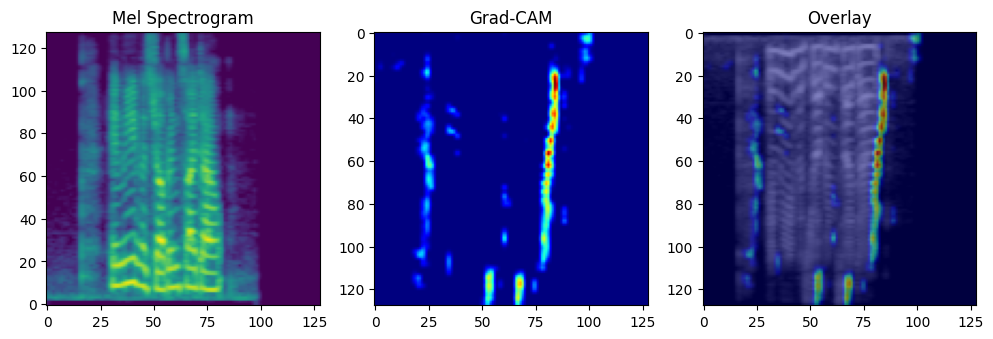


===== SAMPLE 4 =====
True Label: Fake
Prediction: Fake
Confidence: 100.0 %
Explanation:
The model is highly confident in its prediction. It predicts the audio is FAKE because These characteristics are commonly associated with deepfake audio.


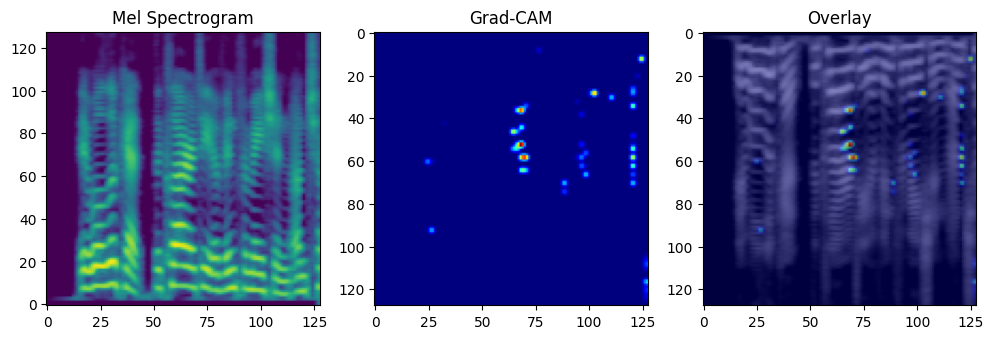

In [23]:
# Test multiple samples
for i in range(5):
    sample, label = val_dataset[i]

    output = model(sample.unsqueeze(0).to(device))
    pred = torch.argmax(output).item()

    probs = torch.softmax(output, dim=1)
    confidence = probs[0][pred].item()

    cam = generate_gradcam(model, sample, pred)

    print(f"\n===== SAMPLE {i} =====")
    print("True Label:", "Fake" if label else "Real")
    print("Prediction:", "Fake" if pred else "Real")
    print("Confidence:", round(confidence * 100, 2), "%")

    print("Explanation:")
    print(generate_explanation(cam, pred, confidence))

    visualize_all(sample.squeeze().numpy(), cam)

### 2.3 FIND CORRECT vs WRONG PREDICTIONS

In [24]:
# Find correct and incorrect predictions
correct_cases = []
wrong_cases = []

for i in range(len(val_dataset)):
    sample, label = val_dataset[i]

    output = model(sample.unsqueeze(0).to(device))
    pred = torch.argmax(output).item()

    if pred == label and len(correct_cases) < 2:
        correct_cases.append((sample, label, pred))
    elif pred != label and len(wrong_cases) < 2:
        wrong_cases.append((sample, label, pred))

    if len(correct_cases) == 2 and len(wrong_cases) == 2:
        break

### 2.4 VISUALIZE CORRECT vs WRONG


CORRECT PREDICTIONS


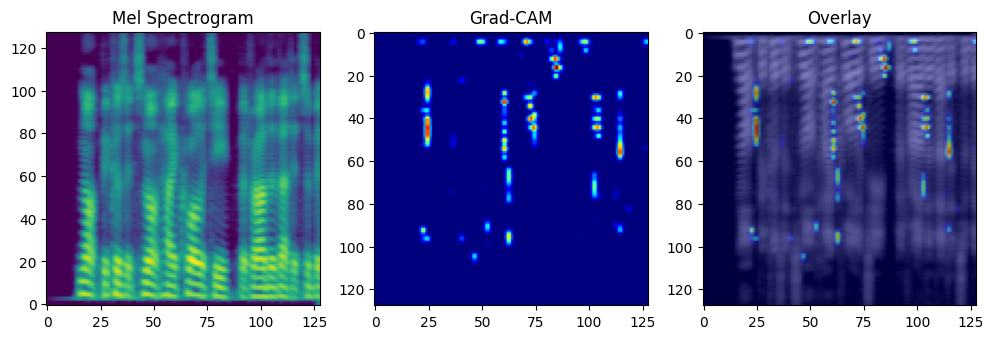

The model is moderately confident. It predicts the audio is FAKE because These characteristics are commonly associated with deepfake audio.


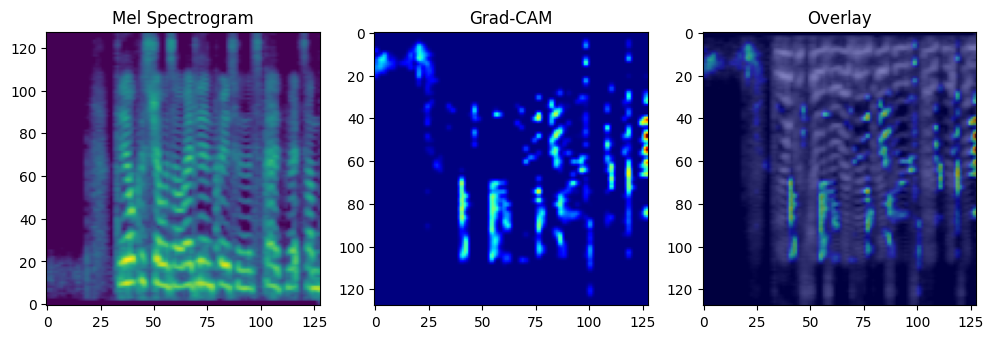

The model is moderately confident. It predicts the audio is FAKE because These characteristics are commonly associated with deepfake audio.

WRONG PREDICTIONS


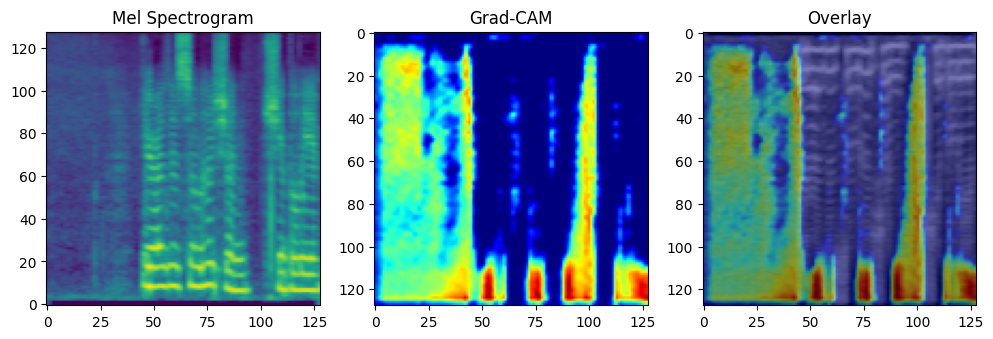

Model struggled here → likely ambiguous audio


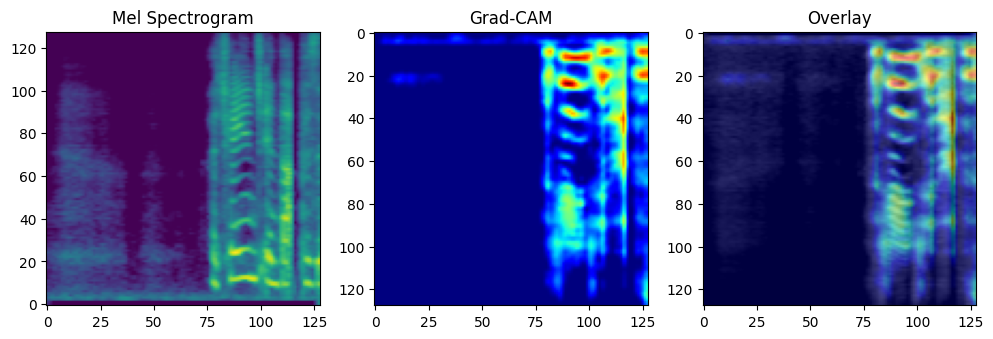

Model struggled here → likely ambiguous audio


In [25]:
print("\nCORRECT PREDICTIONS")
for sample, label, pred in correct_cases:
    cam = generate_gradcam(model, sample, pred)
    visualize_all(sample.squeeze().numpy(), cam)

    print(generate_explanation(cam, pred, 0.9))  # assume high confidence


print("\nWRONG PREDICTIONS")
for sample, label, pred in wrong_cases:
    cam = generate_gradcam(model, sample, pred)
    visualize_all(sample.squeeze().numpy(), cam)

    print("Model struggled here → likely ambiguous audio")

### 2.5 RANDOM SAMPLE TEST

Random Sample Index: 100
True Label: Fake
Prediction: Fake
Confidence: 100.0 %

Explanation:
The model is highly confident in its prediction. It predicts the audio is FAKE because These characteristics are commonly associated with deepfake audio.


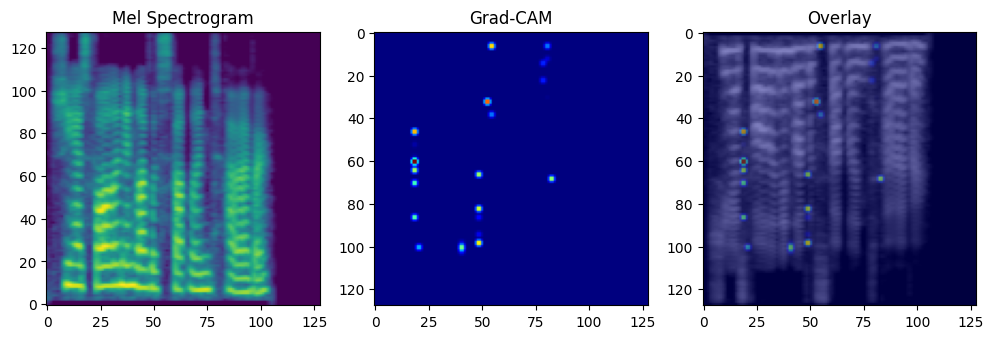

In [27]:
import random

idx = random.randint(0, len(val_dataset)-1)

sample, label = val_dataset[idx]

output = model(sample.unsqueeze(0).to(device))
pred = torch.argmax(output).item()

probs = torch.softmax(output, dim=1)
confidence = probs[0][pred].item()

cam = generate_gradcam(model, sample, pred)

print(f"Random Sample Index: {idx}")
print("True Label:", "Fake" if label else "Real")
print("Prediction:", "Fake" if pred else "Real")
print("Confidence:", round(confidence * 100, 2), "%")

print("\nExplanation:")
print(generate_explanation(cam, pred, confidence))

visualize_all(sample.squeeze().numpy(), cam)